In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import brentq

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
# ─────────────────────────────────────────────
# SHARED PHYSICAL PARAMETERS
# ─────────────────────────────────────────────
lambda0 = 1.55
k0      = 2 * np.pi / lambda0
n_core  = 1.50
n_clad  = 1.45
d       = 2.0
a       = d / 2

Running 2D FDE parameter sweeps...


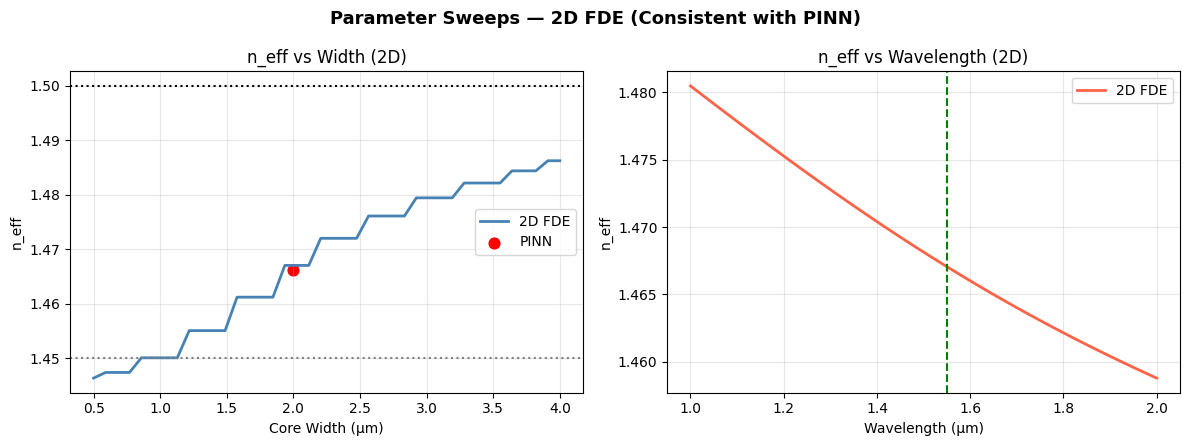

Saved: parameter_sweep_2d.png


In [ ]:
# ─────────────────────────────────────────────
# 1. PARAMETER SWEEPS (2D FDE — CONSISTENT WITH PINN)
# ─────────────────────────────────────────────

import scipy.sparse as sp
import scipy.sparse.linalg as spla

def build_laplacian(Nx, Ny, dx, dy):
    Ix = sp.eye(Nx)
    Iy = sp.eye(Ny)

    Dx = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Nx, Nx)) / dx**2
    Dy = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Ny, Ny)) / dy**2

    return sp.kron(Iy, Dx) + sp.kron(Dy, Ix)


def compute_neff_fde(w_x, w_y, lambda0, Nx=60, Ny=60):
    """Compute n_eff using 2D FDE."""
    k0 = 2 * np.pi / lambda0

    x = np.linspace(-dom2d, dom2d, Nx)
    y = np.linspace(-dom2d, dom2d, Ny)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    XX, YY = np.meshgrid(x, y)

    n_map = np.where((np.abs(XX) <= w_x/2) & (np.abs(YY) <= w_y/2),
                     n_core, n_clad)

    L = build_laplacian(Nx, Ny, dx, dy)

    K = sp.diags((k0**2) * (n_map.flatten()**2))
    A = L + K

    eigvals, _ = spla.eigs(A, k=1, which='LR')
    beta = np.sqrt(np.real(eigvals[0]))

    return beta / k0


print("Running 2D FDE parameter sweeps...")

# Sweep over width
d_vals = np.linspace(0.5, 4.0, 40)
neff_d = []

for dv in d_vals:
    neff_d.append(compute_neff_fde(dv, dv, lambda0))

# Sweep over wavelength
lam_vals = np.linspace(1.0, 2.0, 40)
neff_lam = []

for lv in lam_vals:
    neff_lam.append(compute_neff_fde(w_x, w_y, lv))

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Parameter Sweeps — 2D FDE (Consistent with PINN)", fontsize=13, fontweight='bold')

# Width sweep
axes[0].plot(d_vals, neff_d, 'steelblue', lw=2, label='2D FDE')
axes[0].scatter([w_x], [model2d.beta.item()/k0],
                color='red', s=60, label='PINN')

axes[0].axhline(n_clad, ls=':', color='gray')
axes[0].axhline(n_core, ls=':', color='black')
axes[0].set_xlabel("Core Width (µm)")
axes[0].set_ylabel("n_eff")
axes[0].set_title("n_eff vs Width (2D)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Wavelength sweep
axes[1].plot(lam_vals, neff_lam, 'tomato', lw=2, label='2D FDE')
axes[1].axvline(lambda0, ls='--', color='green')
axes[1].set_xlabel("Wavelength (µm)")
axes[1].set_ylabel("n_eff")
axes[1].set_title("n_eff vs Wavelength (2D)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("parameter_sweep_2d.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: parameter_sweep_2d.png")

Training 2D PINN (1200 epochs)...
  Epoch    0 | Loss: 2.6111e+00 | n_eff: 1.469753
  Epoch  300 | Loss: 3.9314e-02 | n_eff: 1.466367
  Epoch  600 | Loss: 1.7684e-02 | n_eff: 1.466521
  Epoch  900 | Loss: 1.0135e-02 | n_eff: 1.466472
  2D PINN n_eff = 1.466452



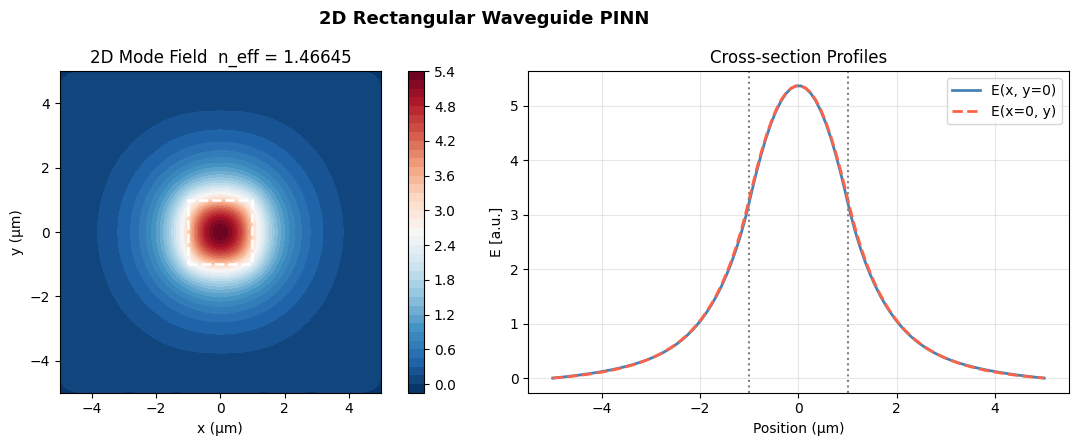

Saved: waveguide_2d.png



In [ ]:
# ─────────────────────────────────────────────
# 2. 2D RECTANGULAR WAVEGUIDE PINN
#    Solves: ∂²E/∂x² + ∂²E/∂y² + k0²n²(x,y)E = β²E
# ─────────────────────────────────────────────

w_x, w_y = 2.0, 2.0    # core dimensions (µm)
dom2d    = 5.0

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 48), nn.Tanh(),
            nn.Linear(48, 48), nn.Tanh(),
            nn.Linear(48, 48), nn.Tanh(),
            nn.Linear(48, 1)
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
        self.beta = nn.Parameter(torch.tensor([k0 * 1.47]))

    def forward(self, xy):
        # Hard-enforce 4-fold symmetry: E(x,y) = E(-x,y) = E(x,-y) = E(-x,-y)
        r1 = self.net(xy)
        r2 = self.net(torch.cat([-xy[:, :1],  xy[:, 1:]], dim=1))
        r3 = self.net(torch.cat([ xy[:, :1], -xy[:, 1:]], dim=1))
        r4 = self.net(torch.cat([-xy[:, :1], -xy[:, 1:]], dim=1))
        return (r1 + r2 + r3 + r4) / 4

def ri_2d(xy):
    inside = (torch.abs(xy[:, 0]) <= w_x / 2) & (torch.abs(xy[:, 1]) <= w_y / 2)
    return torch.where(inside,
                       torch.tensor(n_core, dtype=torch.float32),
                       torch.tensor(n_clad, dtype=torch.float32)).unsqueeze(1)

# Collocation points
xy_bulk   = np.random.uniform(-dom2d, dom2d, (1200, 2))
t_bc      = np.linspace(-dom2d, dom2d, 100)
xy_bc_np  = np.vstack([
    np.c_[t_bc, np.full(100,  dom2d)],
    np.c_[t_bc, np.full(100, -dom2d)],
    np.c_[np.full(100,  dom2d), t_bc],
    np.c_[np.full(100, -dom2d), t_bc],
])

xy_train = torch.tensor(xy_bulk,  dtype=torch.float32, requires_grad=True)
xy_bc    = torch.tensor(xy_bc_np, dtype=torch.float32)

model2d   = PINN2D()
opt2d     = torch.optim.Adam(model2d.parameters(), lr=1e-3)
sched2d   = torch.optim.lr_scheduler.CosineAnnealingLR(opt2d, T_max=1200, eta_min=1e-5)

print("Training 2D PINN (1200 epochs)...")
for ep in range(1200):
    opt2d.zero_grad()

    E2   = model2d(xy_train)
    gE   = torch.autograd.grad(E2, xy_train, torch.ones_like(E2), create_graph=True)[0]
    d2x  = torch.autograd.grad(gE[:, 0:1], xy_train, torch.ones_like(gE[:, 0:1]),
                                create_graph=True)[0][:, 0:1]
    d2y  = torch.autograd.grad(gE[:, 1:2], xy_train, torch.ones_like(gE[:, 1:2]),
                                create_graph=True)[0][:, 1:2]

    n2   = ri_2d(xy_train)
    res2 = d2x + d2y + (k0**2) * (n2**2) * E2 - (model2d.beta**2) * E2

    loss = (torch.mean(res2**2)
            + 20.0 * torch.mean(model2d(xy_bc)**2)
            + 2.0  * (torch.mean(E2**2) - 1.0)**2)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model2d.parameters(), 1.0)
    opt2d.step(); sched2d.step()

    if ep % 300 == 0:
        print(f"  Epoch {ep:4d} | Loss: {loss.item():.4e} | n_eff: {model2d.beta.item()/k0:.6f}")

print(f"  2D PINN n_eff = {model2d.beta.item()/k0:.6f}\n")

# Plot 2D field
Ng = 100
xg = np.linspace(-dom2d, dom2d, Ng)
yg = np.linspace(-dom2d, dom2d, Ng)
XX, YY = np.meshgrid(xg, yg)
xy_grid = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)
with torch.no_grad():
    E2d = model2d(xy_grid).numpy().reshape(Ng, Ng)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("2D Rectangular Waveguide PINN", fontsize=13, fontweight='bold')

cf = axes[0].contourf(XX, YY, E2d, levels=40, cmap='RdBu_r')
plt.colorbar(cf, ax=axes[0])
rect = plt.Rectangle((-w_x/2, -w_y/2), w_x, w_y,
                      fill=False, edgecolor='white', linewidth=1.8, linestyle='--')
axes[0].add_patch(rect)
axes[0].set_title(f"2D Mode Field  n_eff = {model2d.beta.item()/k0:.5f}")
axes[0].set_xlabel("x (µm)"); axes[0].set_ylabel("y (µm)")
axes[0].set_aspect('equal')

mid = Ng // 2
axes[1].plot(xg, E2d[mid, :], 'steelblue', lw=2, label='E(x, y=0)')
axes[1].plot(yg, E2d[:, mid], 'tomato',    lw=2, label='E(x=0, y)', ls='--')
axes[1].axvline(-w_x/2, ls=':', color='gray')
axes[1].axvline( w_x/2, ls=':', color='gray')
axes[1].set_xlabel("Position (µm)"); axes[1].set_ylabel("E [a.u.]")
axes[1].set_title("Cross-section Profiles")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("waveguide_2d.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: waveguide_2d.png\n")


Running efficiency benchmark (2D PINN vs 2D FDE)...
Timing PINN (2D solve)...

===== EFFICIENCY COMPARISON (2D) =====
FDE  — single solve     : 0.063 s
FDE  — 20 sweep pts : 1.484 s  (0.074 s/pt)
PINN — single solve     : 79.237 s
Ratio (PINN / FDE)      : 1264.3× slower


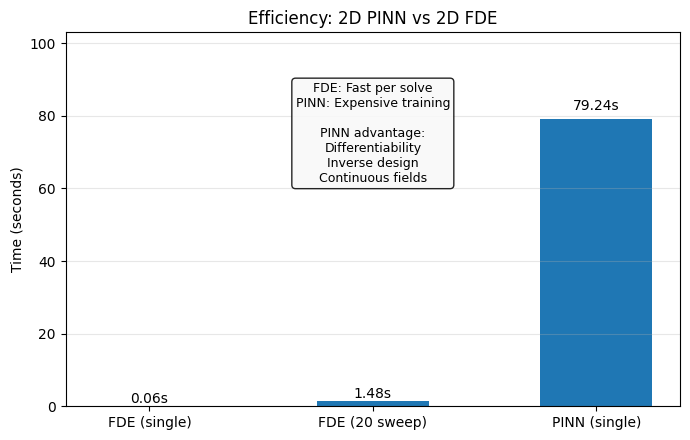

Saved: benchmark_2d.png


In [ ]:
# ─────────────────────────────────────────────
# 3. EFFICIENCY BENCHMARK — PINN vs FDE (2D)
# ─────────────────────────────────────────────

print("\nRunning efficiency benchmark (2D PINN vs 2D FDE)...")

# --------------------------------------------
# FDE timing (single solve)
# --------------------------------------------
def time_fde_solve():
    t0 = time.perf_counter()
    _ = compute_neff_fde(w_x, w_y, lambda0, Nx=60, Ny=60)
    return time.perf_counter() - t0

t_fde_single = time_fde_solve()

# --------------------------------------------
# FDE sweep timing
# --------------------------------------------
N_sweep = 20
d_sweep = np.linspace(0.5, 4.0, N_sweep)

t0 = time.perf_counter()
_ = [compute_neff_fde(dv, dv, lambda0, Nx=60, Ny=60) for dv in d_sweep]
t_fde_sweep = time.perf_counter() - t0

# --------------------------------------------
# PINN timing (single solve)
# (reuse your existing training routine)
# --------------------------------------------
def time_pinn_2d(epochs=1200):
    model = PINN2D()
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

    xy = torch.tensor(np.random.uniform(-dom2d, dom2d, (1200, 2)),
                      dtype=torch.float32, requires_grad=True)

    xy_bc = torch.tensor(xy_bc_np, dtype=torch.float32)

    t0 = time.perf_counter()

    for _ in range(epochs):
        opt.zero_grad()

        E = model(xy)

        gE = torch.autograd.grad(E, xy, torch.ones_like(E), create_graph=True)[0]
        d2x = torch.autograd.grad(gE[:, 0:1], xy, torch.ones_like(gE[:, 0:1]),
                                 create_graph=True)[0][:, 0:1]
        d2y = torch.autograd.grad(gE[:, 1:2], xy, torch.ones_like(gE[:, 1:2]),
                                 create_graph=True)[0][:, 1:2]

        n2 = ri_2d(xy)

        res = d2x + d2y + (k0**2)*(n2**2)*E - (model.beta**2)*E

        loss = (torch.mean(res**2)
                + 20*torch.mean(model(xy_bc)**2)
                + 2*(torch.mean(E**2) - 1.0)**2)

        loss.backward()
        opt.step()

    return time.perf_counter() - t0

print("Timing PINN (2D solve)...")
t_pinn_single = time_pinn_2d(epochs=1200)

# --------------------------------------------
# RESULTS
# --------------------------------------------
print("\n===== EFFICIENCY COMPARISON (2D) =====")
print(f"FDE  — single solve     : {t_fde_single:.3f} s")
print(f"FDE  — {N_sweep} sweep pts : {t_fde_sweep:.3f} s  ({t_fde_sweep/N_sweep:.3f} s/pt)")
print(f"PINN — single solve     : {t_pinn_single:.3f} s")

ratio = t_pinn_single / t_fde_single
print(f"Ratio (PINN / FDE)      : {ratio:.1f}× slower")

# --------------------------------------------
# VISUALIZATION
# --------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

methods = ['FDE (single)', f'FDE ({N_sweep} sweep)', 'PINN (single)']
times   = [t_fde_single, t_fde_sweep, t_pinn_single]

bars = ax.bar(methods, times, width=0.5)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()*1.02,
            f"{t:.2f}s",
            ha='center', va='bottom')

ax.set_ylabel("Time (seconds)")
ax.set_title("Efficiency: 2D PINN vs 2D FDE")
ax.set_ylim(0, max(times)*1.3)
ax.grid(axis='y', alpha=0.3)

ax.text(0.5, 0.6,
        "FDE: Fast per solve\nPINN: Expensive training\n\nPINN advantage:\nDifferentiability\nInverse design\nContinuous fields",
        transform=ax.transAxes,
        ha='center',
        fontsize=9,
        bbox=dict(boxstyle='round', fc='#f9f9f9', alpha=0.85))

plt.tight_layout()
plt.savefig("benchmark_2d.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: benchmark_2d.png")


Running 2D FDE solver for ground truth...
Solving sparse eigenvalue problem...

===== 2D COMPARISON (PINN vs FDE) =====
FDE  n_eff (ground truth) : 1.466847
PINN n_eff                : 1.466452
Absolute Error            : 3.952856e-04
Relative Error            : 0.0269 %
L2 Field Error            : 2.491405e-03


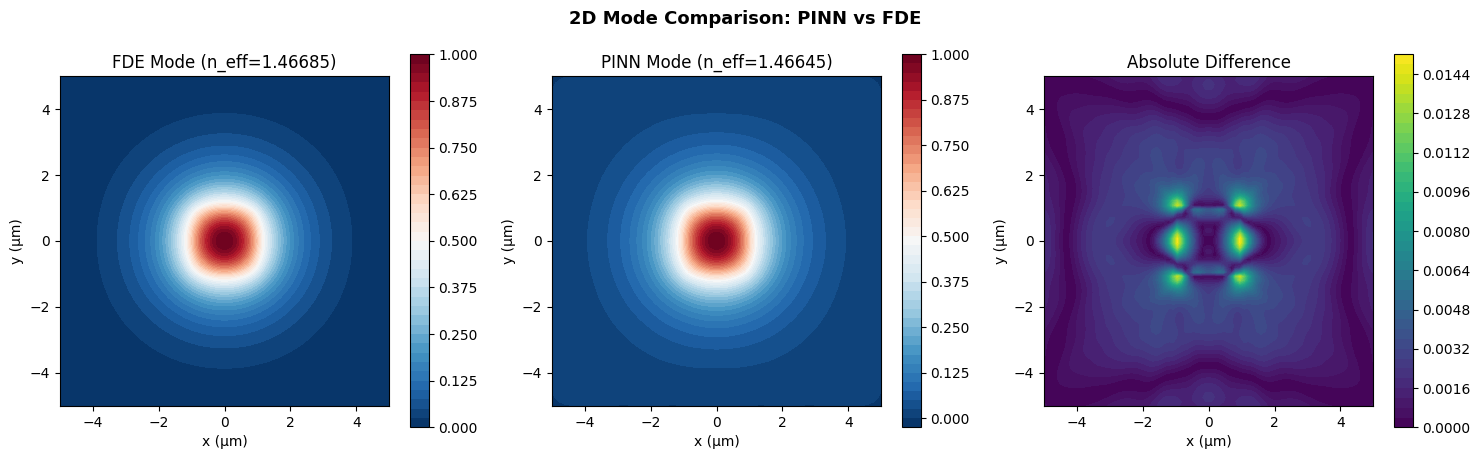

Saved: pinn_vs_fde.png


In [ ]:
# ─────────────────────────────────────────────
# 4. TRUE 2D COMPARISON: PINN vs FDE (Finite Difference Eigenmode)
# ─────────────────────────────────────────────

import scipy.sparse as sp
import scipy.sparse.linalg as spla

print("\nRunning 2D FDE solver for ground truth...")

# Grid
Nx, Ny = 80, 80
x = np.linspace(-dom2d, dom2d, Nx)
y = np.linspace(-dom2d, dom2d, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

XX, YY = np.meshgrid(x, y)

# Refractive index map
n_map = np.where((np.abs(XX) <= w_x/2) & (np.abs(YY) <= w_y/2),
                 n_core, n_clad)

# Flatten grid
N = Nx * Ny

def laplacian_2d(Nx, Ny, dx, dy):
    """Construct sparse 2D Laplacian."""
    Ix = sp.eye(Nx)
    Iy = sp.eye(Ny)

    Dx = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Nx, Nx)) / dx**2
    Dy = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Ny, Ny)) / dy**2

    return sp.kron(Iy, Dx) + sp.kron(Dy, Ix)

# Build operator
L = laplacian_2d(Nx, Ny, dx, dy)

n_flat = n_map.flatten()
K = sp.diags((k0**2) * (n_flat**2))

A = L + K

print("Solving sparse eigenvalue problem...")
eigvals, eigvecs = spla.eigs(A, k=1, which='LR')

beta_fde = np.sqrt(np.real(eigvals[0]))
neff_fde = beta_fde / k0

# ─────────────────────────────────────────────
# COMPARISON
# ─────────────────────────────────────────────

neff_pinn = model2d.beta.item() / k0

abs_err = abs(neff_pinn - neff_fde)
rel_err = abs_err / neff_fde * 100

print("\n===== 2D COMPARISON (PINN vs FDE) =====")
print(f"FDE  n_eff (ground truth) : {neff_fde:.6f}")
print(f"PINN n_eff                : {neff_pinn:.6f}")
print(f"Absolute Error            : {abs_err:.6e}")
print(f"Relative Error            : {rel_err:.4f} %")

# ─────────────────────────────────────────────
# FIELD COMPARISON (FIXED)
# ─────────────────────────────────────────────

# FDE field
E_fde = np.real(eigvecs[:, 0]).reshape(Ny, Nx)

# --- Evaluate PINN on SAME grid ---
xy_grid = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)
with torch.no_grad():
    E_pinn = model2d(xy_grid).numpy().reshape(Ny, Nx)

# --- Normalize both fields ---
E_fde  = E_fde  / np.max(np.abs(E_fde))
E_pinn = E_pinn / np.max(np.abs(E_pinn))

corr = np.sum(E_fde * E_pinn) / np.sqrt(np.sum(E_fde**2) * np.sum(E_pinn**2))
if corr < 0:
    E_pinn = -E_pinn

# --- Compute L2 error ---
l2_error = np.sqrt(np.mean((E_fde - E_pinn)**2))
print(f"L2 Field Error            : {l2_error:.6e}")

# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("2D Mode Comparison: PINN vs FDE", fontsize=13, fontweight='bold')

# FDE field
cf1 = axes[0].contourf(XX, YY, E_fde, levels=40, cmap='RdBu_r')
plt.colorbar(cf1, ax=axes[0])
axes[0].set_title(f"FDE Mode (n_eff={neff_fde:.5f})")

# PINN field (FIXED)
cf2 = axes[1].contourf(XX, YY, E_pinn, levels=40, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1])
axes[1].set_title(f"PINN Mode (n_eff={neff_pinn:.5f})")

# Difference
diff = np.abs(E_fde - E_pinn)
cf3 = axes[2].contourf(XX, YY, diff, levels=40)
plt.colorbar(cf3, ax=axes[2])
axes[2].set_title("Absolute Difference")

for ax in axes:
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("pinn_vs_fde.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: pinn_vs_fde.png")


Computing physics residual map (PINN)...


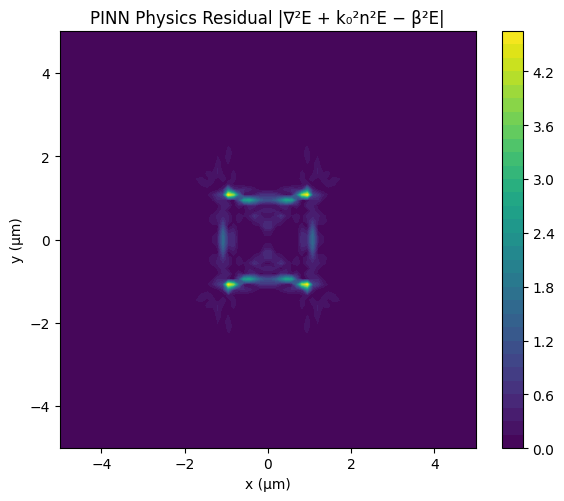

Saved: pinn_residual.png
Residual Mean  : 0.05443577840924263
Residual Max   : 4.595939636230469
Residual Std   : 0.21432243287563324


In [ ]:
# ─────────────────────────────────────────────
# PHYSICS RESIDUAL VISUALIZATION (PINN)
# ─────────────────────────────────────────────

print("\nComputing physics residual map (PINN)...")

# Prepare grid with gradients enabled
xy_res = torch.tensor(np.c_[XX.ravel(), YY.ravel()],
                      dtype=torch.float32, requires_grad=True)

# Forward pass
E_res = model2d(xy_res)

# First derivatives
grads = torch.autograd.grad(E_res, xy_res,
                            torch.ones_like(E_res),
                            create_graph=True)[0]

# Second derivatives (Laplacian)
d2x = torch.autograd.grad(grads[:, 0:1], xy_res,
                          torch.ones_like(grads[:, 0:1]),
                          create_graph=True)[0][:, 0:1]

d2y = torch.autograd.grad(grads[:, 1:2], xy_res,
                          torch.ones_like(grads[:, 1:2]),
                          create_graph=True)[0][:, 1:2]

# Refractive index on grid
n_res = ri_2d(xy_res)

# PDE residual: ∇²E + k0² n² E − β² E
residual = d2x + d2y + (k0**2)*(n_res**2)*E_res - (model2d.beta**2)*E_res

# Convert to numpy
residual_np = residual.detach().numpy().reshape(Ny, Nx)

# Absolute residual (more interpretable)
residual_abs = np.abs(residual_np)

# ─────────────────────────────────────────────
# Plot residual
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(XX, YY, residual_abs, levels=40)
plt.colorbar(cf, ax=ax)

ax.set_title("PINN Physics Residual |∇²E + k₀²n²E − β²E|")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("pinn_residual.png", dpi=200, bbox_inches='tight')
plt.show()

print("Saved: pinn_residual.png")

# ─────────────────────────────────────────────
# Residual metrics
# ─────────────────────────────────────────────

print(f"Residual Mean  : {np.mean(residual_abs)}")
print(f"Residual Max   : {np.max(residual_abs)}")
print(f"Residual Std   : {np.std(residual_abs)}")